# fio rand_write — 3-engine comparison: dfs / dfuse / dfuse+libioil

**Platform:** Aurora (HPE Cray EX), DAOS pool `e2sar`  
**Pattern:** random write (`randwrite`)  
**Config:** bs=1m, numjobs=16, iodepth=16, runtime=60 s, group_reporting  
**Engines:**
- `dfs` — DAOS native userspace ioengine (direct DAOS API)
- `dfuse` — kernel `libaio` via DFuse POSIX mount (no intercept)
- `libioil` — kernel `libaio` via DFuse + `LD_PRELOAD libioil.so` (DAOS intercept lib)

> **Finding:** `libioil` is marginally *slower* than plain DFuse — see Key Findings §5 for root-cause analysis.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path(".")

ENGINE_ORDER  = ["dfs", "dfuse", "libil"]
ENGINE_LABELS = {
    "dfs":   "DFS (native)",
    "dfuse": "DFuse (libaio)",
    "libil": "DFuse+libioil",
}
COLORS = {
    "dfs":   "#1f77b4",
    "dfuse": "#ff7f0e",
    "libil": "#2ca02c",
}

In [2]:
def engine_from_stem(stem: str) -> str:
    """Extract engine tag (dfs / dfuse / libil) from filename stem.
    Handles both fio_libil_* and fio_libioil_* naming conventions."""
    for tag in ENGINE_ORDER:
        if f"_{tag}_" in stem or stem.startswith(f"fio_{tag}_"):
            return tag
    # libioil is the on-disk name; map to libil for consistency
    if "_libioil_" in stem or stem.startswith("fio_libioil_"):
        return "libil"
    return stem  # fallback


def parse_file(fpath: Path) -> dict:
    engine = engine_from_stem(fpath.stem)
    with open(fpath) as f:
        d = json.load(f)
    j = d["jobs"][0]
    w = j["write"]
    pct = w["clat_ns"]["percentile"]
    opts = j["job options"]
    return dict(
        engine        = engine,
        label         = ENGINE_LABELS.get(engine, engine),
        ioengine      = opts.get("ioengine", "?"),
        bs            = opts.get("bs", "?"),
        numjobs       = int(opts.get("numjobs", 0)),
        iodepth       = int(opts.get("iodepth", 0)),
        bw_GiBs       = w["bw_bytes"] / 1024**3,
        iops          = w["iops"],
        lat_mean_ms   = w["lat_ns"]["mean"]  / 1e6,
        clat_mean_ms  = w["clat_ns"]["mean"] / 1e6,
        slat_mean_us  = w["slat_ns"]["mean"] / 1e3,
        clat_p50_ms   = pct["50.000000"]     / 1e6,
        clat_p90_ms   = pct["90.000000"]     / 1e6,
        clat_p95_ms   = pct["95.000000"]     / 1e6,
        clat_p99_ms   = pct["99.000000"]     / 1e6,
        clat_p999_ms  = pct["99.900000"]     / 1e6,
        clat_p9999_ms = pct["99.990000"]     / 1e6,
        usr_cpu       = j["usr_cpu"],
        sys_cpu       = j["sys_cpu"],
        total_ios     = w["total_ios"],
    )


rows = [parse_file(f) for f in sorted(RESULTS_DIR.glob("fio_*.json"))]
df = pd.DataFrame(rows)
df["engine"] = pd.Categorical(df["engine"], categories=ENGINE_ORDER, ordered=True)
df = df.sort_values("engine").reset_index(drop=True)
df

,engine,label,ioengine,bs,numjobs,iodepth,bw_GiBs,iops,lat_mean_ms,clat_mean_ms,slat_mean_us,clat_p50_ms,clat_p90_ms,clat_p95_ms,clat_p99_ms,clat_p999_ms,clat_p9999_ms,usr_cpu,sys_cpu,total_ios
0,dfs,DFS (native),dfs,1m,16,16,89.475946,91623.368832,2.652201,2.637467,14.734372,2.473984,3.522560,4.046848,5.537792,12.910592,51.118080,95.379750,1.654978,5497677
1,dfuse,DFuse (libaio),libaio,1m,16,16,14.671744,15023.865871,16.753990,15.968224,785.765962,15.925248,17.432576,17.956864,19.267584,20.578304,21.889024,25.884283,1.279563,901462
2,libil,DFuse+libioil,libaio,1m,16,16,14.312061,14655.550556,17.148859,16.310096,838.763349,16.187392,18.481152,19.005440,20.054016,21.626880,22.937600,22.556916,1.238834,879377


## Bandwidth, IOPS, and Mean Latency

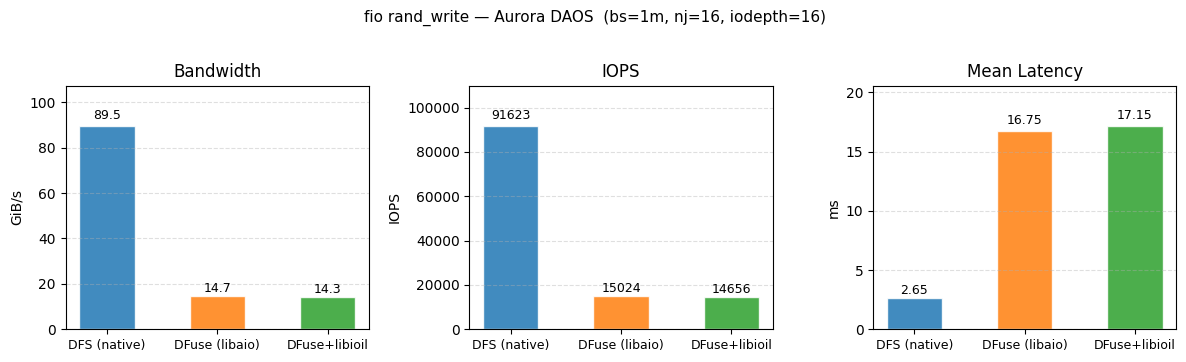

In [3]:
engines = [e for e in ENGINE_ORDER if e in df["engine"].values]
labels  = [ENGINE_LABELS[e] for e in engines]
x = np.arange(len(engines))
bar_w = 0.5

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

metrics = [
    ("bw_GiBs",     "GiB/s", "Bandwidth",    ".1f"),
    ("iops",        "IOPS",  "IOPS",         ".0f"),
    ("lat_mean_ms", "ms",    "Mean Latency", ".2f"),
]

for ax, (col, ylabel, title, fmt) in zip(axes, metrics):
    vals = [df[df.engine == e][col].values[0] for e in engines]
    bars = ax.bar(x, vals, bar_w,
                  color=[COLORS[e] for e in engines], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                format(v, fmt), ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle("fio rand_write — Aurora DAOS  (bs=1m, nj=16, iodepth=16)", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_3engines_rw_bw_iops_lat.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Completion Latency Percentiles (clat)

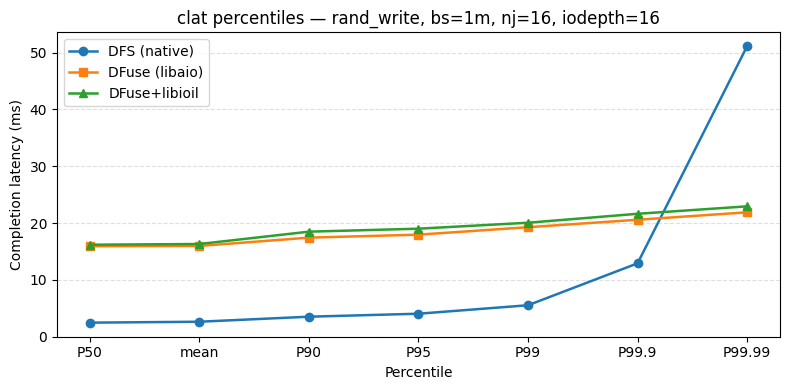

In [6]:
pct_cols   = ["clat_p50_ms", "clat_mean_ms", "clat_p90_ms",
              "clat_p95_ms", "clat_p99_ms",  "clat_p999_ms", "clat_p9999_ms"]
pct_labels = ["P50", "mean", "P90", "P95", "P99", "P99.9", "P99.99"]
markers    = {"dfs": "o", "dfuse": "s", "libil": "^"}   

fig, ax = plt.subplots(figsize=(8, 4))

for engine in engines:
    row  = df[df.engine == engine].iloc[0]
    vals = [row[c] for c in pct_cols]
    ax.plot(pct_labels, vals,
            marker=markers.get(engine, "o"),
            label=ENGINE_LABELS[engine],
            color=COLORS[engine],
            linewidth=1.8, markersize=6)
    # for xi, v in enumerate(vals):
        # ax.annotate(f"{v:.1f}", (xi, v),
                    # textcoords="offset points", xytext=(0, 6),
                    # ha="center", fontsize=7.5, color=COLORS[engine])

ax.set_xlabel("Percentile")
ax.set_ylabel("Completion latency (ms)")
ax.set_title("clat percentiles — rand_write, bs=1m, nj=16, iodepth=16")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_3engines_rw_clat_pct.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Submission Latency and CPU Usage

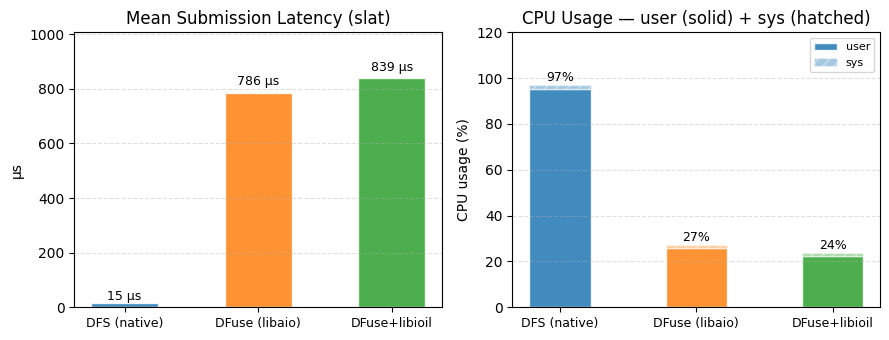

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# slat
ax = axes[0]
vals = [df[df.engine == e]["slat_mean_us"].values[0] for e in engines]
bars = ax.bar(x, vals, bar_w, color=[COLORS[e] for e in engines], alpha=0.85, edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f"{v:.0f} µs", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("µs")
ax.set_title("Mean Submission Latency (slat)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, max(vals) * 1.2)

# CPU
ax = axes[1]
bar_w2 = 0.35
usr_vals = [df[df.engine == e]["usr_cpu"].values[0] for e in engines]
sys_vals = [df[df.engine == e]["sys_cpu"].values[0] for e in engines]
ax.bar(x, usr_vals, bar_w2 + 0.1, label="user",
       color=[COLORS[e] for e in engines], alpha=0.85, edgecolor="white")
ax.bar(x, sys_vals, bar_w2 + 0.1, bottom=usr_vals,
       color=[COLORS[e] for e in engines], alpha=0.4, hatch="///",
       edgecolor="white", label="sys")
for i, (u, s) in enumerate(zip(usr_vals, sys_vals)):
    ax.text(i, u + s + 0.5, f"{u+s:.0f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("CPU usage (%)")
ax.set_title("CPU Usage — user (solid) + sys (hatched)")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.set_ylim(0, 120)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio_3engines_rw_slat_cpu.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings

**Setup:** fio random write, bs=1m, numjobs=16, iodepth=16, runtime=60 s, group\_reporting.  
Aurora DAOS pool `e2sar`. Results collected 2026-06-17.

---

### 1. DFS is 6× faster than both POSIX-path engines

| Engine | BW | IOPS | Mean lat | slat | usr+sys CPU |
|--------|------|------|----------|------|-------------|
| DFS (native)   | **89.5 GiB/s** | **91,623** | **2.65 ms** | 14.7 µs  | 97.0% |
| DFuse (libaio) |  14.7 GiB/s   |  15,024    | 16.75 ms   | 785.8 µs | 27.2% |
| DFuse+libioil  |  14.3 GiB/s   |  14,656    | 17.15 ms   | 838.8 µs | 23.8% |

The DAOS native `dfs` ioengine bypasses FUSE entirely and issues RDMA operations directly from userspace. With 256 in-flight IOs (nj=16 × iodepth=16) it delivers 6.1× the bandwidth of either FUSE-path engine.

### 2. FUSE submission latency is the throughput ceiling for the POSIX path
Mean **submission latency** for DFuse = **785.8 µs** versus **14.7 µs** for DFS (53×).  
Each IO dispatched through the FUSE kernel module requires a context switch into the DFuse daemon and back. This per-IO overhead caps IOPS at ~15 K regardless of iodepth — adding more queue depth does not help because slat dominates the round-trip time.

### 3. DFS tail latency is wider despite the lower mean
DFuse clat distribution is narrow and consistent (p50 = 15.9 ms, p99.99 = 21.9 ms, spread = 6 ms).  
DFS is faster on average (p50 = 2.5 ms) but has a long tail (p99.99 = 51.1 ms, spread = 49 ms).  
Occasional DFS outliers likely reflect DAOS client retransmission or fabric jitter under 256-IO concurrency.

### 4. DFS trades CPU for throughput
At ~97% CPU per node (95.4 usr + 1.7 sys), DFS consumes ~3.6× more CPU than the FUSE path (~27%) to deliver 6× the bandwidth. The RDMA userspace path requires active polling. Both FUSE engines run at roughly equal CPU cost (~25–27%).

### 5. `libioil` is slower than plain DFuse — intercept/engine mismatch

**Observed:** `libioil` is **~2.5% slower** than plain DFuse (14.31 vs 14.67 GiB/s) and its **slat is higher** (838.8 µs vs 785.8 µs, +53 µs).

**Root cause:** fio's `libaio` engine submits I/O via kernel AIO syscalls (`io_submit` / `io_getevents`). `libioil` only intercepts POSIX blocking calls (`write`, `pwrite`, …) — it has no hook for kernel AIO. The actual data transfer still travels through FUSE unchanged. The +53 µs slat regression comes from libioil's per-`open()`/`close()` fd-tracking overhead running on every file descriptor, with no offsetting benefit.

> For application code that calls `pwrite()` directly (not via kernel AIO), `libioil` can still accelerate POSIX I/O over plain DFuse by bypassing the FUSE context switch.

### 6. `libpil4dfs` causes fio to quit silently — fork-safety violation

**Observed:** fio exits immediately with zero I/O when `LD_PRELOAD=libpil4dfs.so`.

**Root cause — `daos_init()` is not fork-safe:**

`libpil4dfs` calls `daos_init()` in its ELF constructor (`__attribute__((constructor))`), which opens a persistent Unix-domain socket connection to the local DAOS agent. fio then forks 16 worker processes (`--numjobs=16`). Each forked child inherits:
- the parent's open file descriptors (including the DAOS agent socket)
- the parent's in-memory DAOS client state (sequence numbers, pool handles, …)

Two processes sharing a single Unix socket connection cause undefined behavior in the DAOS protocol. `libpil4dfs` (or the DAOS client library via a `pthread_atfork` handler) detects the post-fork inconsistency and calls `_exit(0)` in each child before any I/O is attempted — silently, with exit code 0. fio's parent sees all 16 workers finish immediately and reports zero throughput (or exits cleanly with no output file).

This is distinct from a crash: there is no error message because `_exit(0)` bypasses stdio flushing and atexit handlers.

**Contrast with `libioil`:** `libioil` defers `daos_init()` until the first intercepted POSIX call hits a DAOS-backed file descriptor. Since fio's `libaio` engine never calls `write()`, `daos_init()` is never triggered — the library loads, does nothing, survives the fork, and fio runs normally (but without any DAOS acceleration).

**Potential workaround — `fio --thread` + `psync`/`pvsync`:**  
Adding `--thread` makes fio use `pthread_create` instead of `fork` for worker processes, avoiding the fork-unsafe DAOS state issue. Switching to `--ioengine=psync` or `--ioengine=pvsync` (which use `pwrite()`/`pwritev()`) gives `libpil4dfs` a POSIX call path to intercept. The tradeoff is `iodepth` is limited to 1 — concurrency must come from `--numjobs` alone.